# Replicate the paper's category-cell selection (hippocampus + amygdala)

Reproduce the published **category-cell** selection to line up with the paper's numbers before we
layer cell-typing on top.

**Method (exactly as published):**
- For every **picture presentation** — all encoding stimuli (Encoding1/2/3) **and the probe** —
  count spikes in **200–1000 ms** after onset; label each by its picture **category** (PicID // 100).
- **Test 1:** 1×5 **permutation ANOVA**, category as grouping variable.
- **Test 2 (post hoc):** one-sided **permutation t-test**, max-count category vs all others pooled.
- **Category cell = both P < 0.05** (**2,000 permutations**). Preferred = max-FR category.
- Selection uses **encoding + probe presentations only** — maintenance is held out (independent for
  later analyses).

We run it on **hippocampus and amygdala** and report the per-area counts. (No per-area shuffle
chance test — that's a separate population claim the paper already established; the per-neuron test
alone fixes the cell count.) Cell-typing is **not** applied here — it wires in later by joining
`unit_labels_*.csv` on `unit_id`.

## Section 0 — Setup

In [1]:
# [0.1] imports, config
import sys, warnings, time, json
from pathlib import Path
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

PROJECT = Path.cwd()                        # run from E:\SBCAT\celltyping
if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))
from celltyping.selectivity import (load_spikes_trials, pooled_presentations,
                                    category_selectivity, psth)

RS = 42
plt.rcParams['figure.dpi'] = 100

# ---- CONFIG (paper's category-cell selection) ----
DATASET   = '000673'
DATA_ROOT = PROJECT.parent / 'data' / DATASET
OUT_DIR   = PROJECT / 'outputs' / 'celltype'
SELECT_AREAS = ['hippocampus', 'amygdala']   # our replication scope (paper reports 5 areas)
CATS      = (1, 2, 3, 4, 5)                  # visual categories = PicID // 100
RESP_WIN  = (0.2, 1.0)                       # 200-1000 ms after every stimulus onset
N_PERM    = 200                            # paper: 2,000 permutations
ALPHA     = 0.05
MIN_TRIALS = 5                               # min presentations/category (rarely binding when pooled)
INCLUDE_PROBE = True                         # encoding + probe presentations
print(f'{DATASET} | areas={SELECT_AREAS} | win={RESP_WIN}s | {N_PERM} perms | probe={INCLUDE_PROBE}')

000673 | areas=['hippocampus', 'amygdala'] | win=(0.2, 1.0)s | 200 perms | probe=True


In [2]:
# [0.2] all session files
files = sorted(DATA_ROOT.glob('sub-*/*.nwb'))
assert files, f'no NWB files under {DATA_ROOT}'
print(f'{len(files)} session files under {DATA_ROOT}')

44 session files under e:\SBCAT\data\000673


## Section 1 — Load spikes + trials

In [3]:
# [1.1] load spike times + per-session trials (H + A units)
t0 = time.time()
units_df, spikes, trials_by_session = load_spikes_trials(files, areas=SELECT_AREAS, verbose=True)
# area label from electrode location
def _area(loc):
    s = str(loc).lower()
    return 'hippocampus' if 'hippocampus' in s else ('amygdala' if 'amygdala' in s else 'other')
units_df['area'] = units_df.location.map(_area)
units_df = units_df.reset_index(drop=True)          # aligned to `spikes`
print(f'\n{len(units_df)} units in {time.time()-t0:.0f}s | by area: {units_df.area.value_counts().to_dict()}')

  sub-1_ses-1_ecephys+image: 22 units, 140 trials
  sub-1_ses-2_ecephys+image: 26 units, 140 trials
  sub-10_ses-1_ecephys+image: 23 units, 140 trials
  sub-11_ses-1_ecephys+image: 15 units, 139 trials
  sub-12_ses-1_ecephys+image: 15 units, 140 trials
  sub-12_ses-2_ecephys+image: 6 units, 140 trials
  sub-13_ses-1_ecephys+image: 3 units, 140 trials
  sub-14_ses-1_ecephys+image: 4 units, 140 trials
  sub-15_ses-1_ecephys+image: 22 units, 140 trials
  sub-16_ses-1_ecephys+image: 30 units, 140 trials
  sub-17_ses-1_ecephys+image: 45 units, 140 trials
  sub-18_ses-1_ecephys+image: 27 units, 140 trials
  sub-19_ses-1_ecephys+image: 45 units, 140 trials
  sub-19_ses-2_ecephys+image: 32 units, 140 trials
  sub-2_ses-1_ecephys+image: 25 units, 140 trials
  sub-20_ses-1_ecephys+image: 28 units, 140 trials
  sub-21_ses-1_ecephys+image: 40 units, 140 trials
  sub-22_ses-1_ecephys+image: 42 units, 128 trials
  sub-22_ses-2_ecephys+image: 13 units, 140 trials
  sub-22_ses-3_ecephys+image: 13 unit

## Section 2 — Category-cell selection (per neuron)

In [4]:
# [2.1] pooled enc+probe presentations -> ANOVA + post-hoc max-vs-rest (2000 perms) per neuron
recs = []
for j, row in units_df.iterrows():
    on, cat = pooled_presentations(trials_by_session.get(row.session_id), keep=CATS,
                                   include_probe=INCLUDE_PROBE)
    sel = category_selectivity(spikes[j], on, cat, win=RESP_WIN, min_trials=MIN_TRIALS,
                               n_perm=N_PERM, alpha=ALPHA, seed=RS)
    recs.append(dict(unit_id=row.unit_id, session_id=row.session_id, subject=row.subject,
                     location=row.location, area=row.area, n_pres=int(on.size),
                     anova_p=sel['anova_p'], pref_p=sel['pref_p'], selective=sel['selective'],
                     pref_cat=sel['pref_cat'], dos=sel['dos'], n_cat=sel['n_cat'],
                     tested=sel['tested']))
sel_df = pd.DataFrame(recs)
n_tested = int(sel_df.tested.sum())
print(f'{n_tested}/{len(sel_df)} units tested | {int(sel_df.selective.sum())} category cells '
      f'(ANOVA & post-hoc max-vs-rest, both p<{ALPHA})')
print(f'median presentations/unit: {int(sel_df.n_pres.median())}')
sel_df.sort_values("anova_p").head(10)

856/856 units tested | 269 category cells (ANOVA & post-hoc max-vs-rest, both p<0.05)
median presentations/unit: 420


,unit_id,session_id,subject,location,area,n_pres,anova_p,pref_p,selective,pref_cat,dos,n_cat,tested
27,sub-1_ses-2_ecephys+image_u015,sub-1_ses-2_ecephys+image,sub-1,amygdala_right,amygdala,420,0.004975,0.014925,True,3,0.156802,5,True
28,sub-1_ses-2_ecephys+image_u016,sub-1_ses-2_ecephys+image,sub-1,amygdala_right,amygdala,420,0.004975,0.014925,True,5,0.258484,5,True
31,sub-1_ses-2_ecephys+image_u019,sub-1_ses-2_ecephys+image,sub-1,amygdala_right,amygdala,420,0.004975,0.109453,False,5,0.128893,5,True
11,sub-1_ses-1_ecephys+image_u033,sub-1_ses-1_ecephys+image,sub-1,amygdala_right,amygdala,420,0.004975,0.024876,True,5,0.240590,5,True
823,sub-8_ses-1_ecephys+image_u005,sub-8_ses-1_ecephys+image,sub-8,amygdala_left,amygdala,420,0.004975,0.004975,True,2,0.448818,5,True
822,sub-8_ses-1_ecephys+image_u004,sub-8_ses-1_ecephys+image,sub-8,amygdala_left,amygdala,420,0.004975,0.004975,True,2,0.264560,5,True
825,sub-8_ses-1_ecephys+image_u007,sub-8_ses-1_ecephys+image,sub-8,amygdala_left,amygdala,420,0.004975,0.004975,True,2,0.365456,5,True
834,sub-8_ses-1_ecephys+image_u016,sub-8_ses-1_ecephys+image,sub-8,hippocampus_left,hippocampus,420,0.004975,0.004975,True,1,0.543704,5,True
385,sub-21_ses-1_ecephys+image_u017,sub-21_ses-1_ecephys+image,sub-21,amygdala_right,amygdala,420,0.004975,0.004975,True,4,0.869332,5,True
625,sub-31_ses-1_ecephys+image_u006,sub-31_ses-1_ecephys+image,sub-31,amygdala_left,amygdala,420,0.004975,0.004975,True,1,0.318560,5,True


       area  n_units  n_category_cells  pct
hippocampus      360                90 25.0
   amygdala      496               179 36.1

total (H+A): 269 / 856 (31.4%)


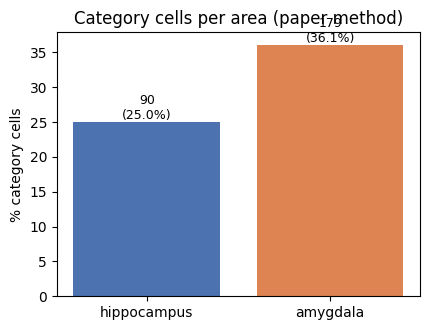

In [5]:
# [2.2] category-cell counts per area (the replication table)
rows = []
for area in ['hippocampus', 'amygdala']:
    a = sel_df[(sel_df.area == area) & sel_df.tested]
    rows.append(dict(area=area, n_units=len(a), n_category_cells=int(a.selective.sum()),
                     pct=100 * a.selective.mean() if len(a) else np.nan))
tab = pd.DataFrame(rows)
print(tab.round(1).to_string(index=False))
print(f"\ntotal (H+A): {int(sel_df[sel_df.tested].selective.sum())} / {n_tested} "
      f"({100*sel_df[sel_df.tested].selective.mean():.1f}%)")
fig, ax = plt.subplots(figsize=(4.4, 3.4))
ax.bar(tab.area, tab.pct, color=['#4c72b0', '#dd8452'])
for x, (n, p) in enumerate(zip(tab.n_category_cells, tab.pct)):
    ax.text(x, p, f'{n}\n({p:.1f}%)', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('% category cells'); ax.set_title('Category cells per area (paper method)')
fig.tight_layout(); plt.show()

In [6]:
# [2.3] preferred-category breakdown per area (sanity: spread across the 5 categories)
cc = sel_df[sel_df.selective]
print('preferred category of category cells, per area:')
print(pd.crosstab(cc.area, cc.pref_cat.astype('Int64')).to_string())

preferred category of category cells, per area:
pref_cat      1   2   3   4   5
area                           
amygdala     52  39  24  36  28
hippocampus  33  16  18  13  10


## Section 3 — Sanity check: example category cells

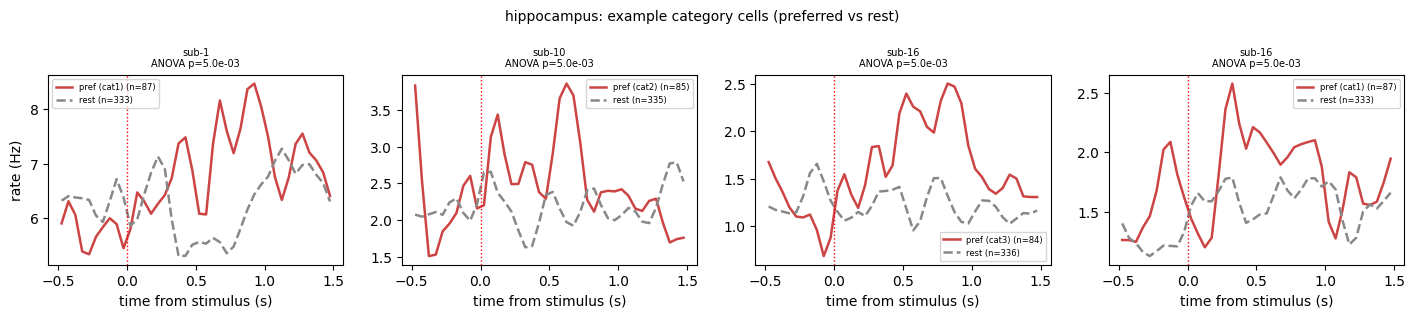

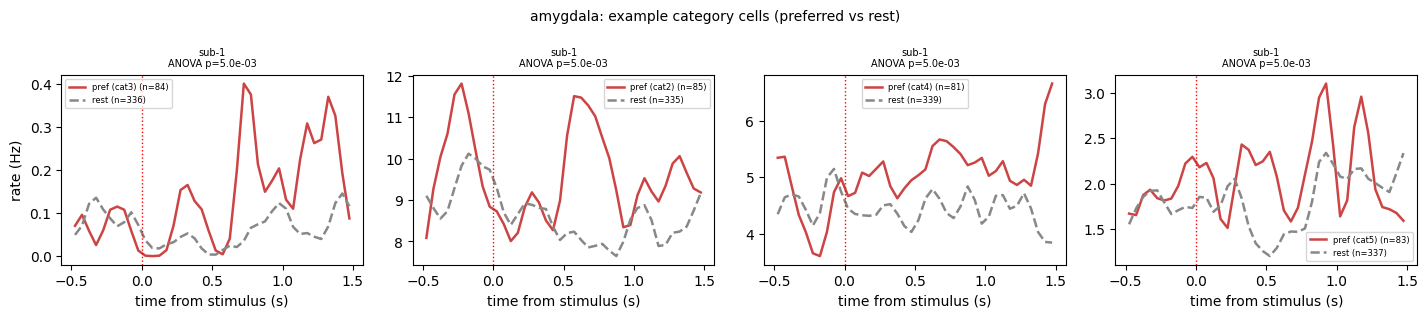

In [7]:
# [3.1] most-significant category cells per area: preferred category vs rest (presentation-aligned)
uid2idx = {u: i for i, u in enumerate(units_df.unit_id)}
PSTH_WIN = (-0.5, 1.5); BIN_MS = 50.0; SIGMA_MS = 50.0
for area in ['hippocampus', 'amygdala']:
    top = sel_df[(sel_df.area == area) & sel_df.selective].sort_values('anova_p').head(4)
    if not len(top):
        print(f'no category cells in {area}'); continue
    fig, axes = plt.subplots(1, len(top), figsize=(3.6 * len(top), 3.2), squeeze=False)
    for ax, (_, row) in zip(axes[0], top.iterrows()):
        on, cat = pooled_presentations(trials_by_session.get(row.session_id), keep=CATS,
                                       include_probe=INCLUDE_PROBE)
        spk = spikes[uid2idx[row.unit_id]]
        for onset_set, name, col, ls in ((on[cat == row.pref_cat], f'pref (cat{int(row.pref_cat)})', '#c44', '-'),
                                         (on[cat != row.pref_cat], 'rest', '#888', '--')):
            if onset_set.size:
                r, t = psth(spk, onset_set, window=PSTH_WIN, bin_ms=BIN_MS, sigma_ms=SIGMA_MS)
                ax.plot(t, r, color=col, ls=ls, lw=1.8, label=f'{name} (n={onset_set.size})')
        ax.axvline(0, color='r', ls=':', lw=1)
        ax.set_title(f"{row.unit_id.split('_ses')[0]}\nANOVA p={row.anova_p:.1e}", fontsize=7)
        ax.set_xlabel('time from stimulus (s)'); ax.legend(fontsize=6)
    axes[0][0].set_ylabel('rate (Hz)')
    fig.suptitle(f'{area}: example category cells (preferred vs rest)', fontsize=10)
    fig.tight_layout(); plt.show()

## Section 4 — Save

In [8]:
# [4.1] save per-neuron category-cell table (keyed on unit_id; ready to join cell-type labels later)
region_tag = '+'.join(a.lower() for a in SELECT_AREAS)
OUT_DIR.mkdir(parents=True, exist_ok=True)
out = OUT_DIR / f'category_cells_{region_tag}.csv'
sel_df.to_csv(out, index=False)
prov = dict(dataset=DATASET, areas=SELECT_AREAS, method='paper category-cell selection '
            '(perm ANOVA + post-hoc one-sided max-vs-rest t-test, both p<0.05)',
            resp_win=list(RESP_WIN), n_perm=N_PERM, include_probe=INCLUDE_PROBE, min_trials=MIN_TRIALS,
            n_units=int(len(sel_df)), n_tested=n_tested, n_category_cells=int(sel_df.selective.sum()),
            per_area={r.area: dict(n_units=int(r.n_units), n_category_cells=int(r.n_category_cells))
                      for r in tab.itertuples()})
out.with_suffix('.json').write_text(json.dumps(prov, indent=2, default=float))
print(f'wrote {out}  ({int(sel_df.selective.sum())} category cells / {n_tested} tested)')
sel_df.head(12)

wrote e:\SBCAT\celltyping\outputs\celltype\category_cells_hippocampus+amygdala.csv  (269 category cells / 856 tested)


,unit_id,session_id,subject,location,area,n_pres,anova_p,pref_p,selective,pref_cat,dos,n_cat,tested
0,sub-1_ses-1_ecephys+image_u022,sub-1_ses-1_ecephys+image,sub-1,amygdala_right,amygdala,420,0.606965,1.000000,False,4,0.143466,5,True
1,sub-1_ses-1_ecephys+image_u023,sub-1_ses-1_ecephys+image,sub-1,amygdala_right,amygdala,420,0.875622,1.000000,False,2,0.228625,5,True
2,sub-1_ses-1_ecephys+image_u024,sub-1_ses-1_ecephys+image,sub-1,amygdala_right,amygdala,420,0.333333,1.000000,False,1,0.110096,5,True
3,sub-1_ses-1_ecephys+image_u025,sub-1_ses-1_ecephys+image,sub-1,amygdala_right,amygdala,420,0.024876,0.014925,True,5,0.250994,5,True
4,sub-1_ses-1_ecephys+image_u026,sub-1_ses-1_ecephys+image,sub-1,amygdala_right,amygdala,420,0.019900,0.084577,False,2,0.211101,5,True
5,sub-1_ses-1_ecephys+image_u027,sub-1_ses-1_ecephys+image,sub-1,amygdala_right,amygdala,420,0.512438,1.000000,False,4,0.299819,5,True
6,sub-1_ses-1_ecephys+image_u028,sub-1_ses-1_ecephys+image,sub-1,amygdala_right,amygdala,420,0.049751,0.009950,True,1,0.347350,5,True
7,sub-1_ses-1_ecephys+image_u029,sub-1_ses-1_ecephys+image,sub-1,amygdala_right,amygdala,420,0.233831,1.000000,False,5,0.121262,5,True
8,sub-1_ses-1_ecephys+image_u030,sub-1_ses-1_ecephys+image,sub-1,amygdala_right,amygdala,420,0.298507,1.000000,False,3,0.077556,5,True
9,sub-1_ses-1_ecephys+image_u031,sub-1_ses-1_ecephys+image,sub-1,amygdala_right,amygdala,420,0.029851,0.024876,True,3,0.252651,5,True


## Reading the result

- **`[2.2]`** is the replication target — compare the hippocampus / amygdala **category-cell counts
  (and %)** against the paper's reported numbers. Expect a close match, not an exact integer:
  permutation tests are stochastic at the P = 0.05 boundary and unit-inclusion choices shift it a
  little. A large gap flags a real methodological difference (window, probe inclusion, category map).
- **`[2.3]`** checks the preferred categories are spread across all 5 (not an artifact of one).
- **`[3.1]`** eyeballs that selected cells show a genuine preferred-vs-rest response.
- Output `category_cells_<region>.csv` has the per-neuron selection keyed on `unit_id`. **Cell-typing
  wires in later** by joining `unit_labels_*.csv` (e.g. `costas_class`) on `unit_id` and splitting
  the category cells by type — no change to the selection needed.